In [3]:
from pathlib import Path
import pandas as pd

INPUT_ROOT = Path(r"N:\01_scientific_data\Sarah_Kralova_brain_slice_data\cellpose + far-red channel")
HISTOGRAM_ROOT = INPUT_ROOT / "histograms"
folder = HISTOGRAM_ROOT  # replace with your folder path

dfs = []
for csv_file in folder.glob("*_props.csv"):
    df = pd.read_csv(csv_file)
    df["image"] = csv_file.stem.removesuffix("_props")
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
combined_df

,label,area,num_pixels,dapi_positive_overlap,valid,tissue_area_um2,intensity_mean_dapi,intensity_std_dapi,intensity_p10_dapi,intensity_p20_dapi,...,intensity_p40_farred,intensity_p50_farred,intensity_p60_farred,intensity_p70_farred,intensity_p80_farred,intensity_p90_farred,intensity_p92_farred,intensity_p95_farred,intensity_p98_farred,image
0,1,427.458073,3695,False,True,217607.686243,330.125034,278.090183,125.0,137.0,...,447.0,599.0,930.0,1433.0,2188.4,2989.0,3118.96,3400.0,3764.60,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...
1,2,731.711046,6325,False,True,217607.686243,278.119526,206.686406,121.0,130.0,...,470.6,555.0,719.4,925.0,1229.4,1857.0,2001.00,2241.0,2591.52,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...
2,3,348.676220,3014,True,True,217607.686243,441.251161,325.328847,169.0,214.0,...,973.2,1341.0,1748.4,2319.1,3182.4,3834.8,3996.92,4251.7,4668.76,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...
3,4,546.267124,4722,False,True,217607.686243,305.121135,262.122726,130.0,143.0,...,605.4,824.5,1119.0,1469.0,1902.8,2490.9,2637.32,2894.9,3366.48,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...
4,5,563.272898,4869,True,True,217607.686243,360.472992,291.992864,146.0,172.0,...,854.0,1151.0,1521.8,2005.6,2548.8,3259.0,3534.24,4083.8,5919.92,0248_CHST11KO+P301S_HC_AT8_zeta2_first_2026-04...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33397,3994,227.040704,1959,False,False,90567.732187,125.917305,16.333942,113.0,115.0,...,153.0,161.0,168.0,175.0,187.0,203.0,211.00,221.0,237.00,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
33398,3995,276.180704,2383,False,False,90567.732187,137.158204,10.989740,123.0,128.0,...,167.0,173.0,178.0,184.0,193.0,206.0,209.00,215.0,225.00,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
33399,3996,227.504289,1963,False,False,90567.732187,122.182883,11.011811,112.0,114.0,...,180.0,185.0,191.0,197.0,205.0,217.0,220.00,228.9,239.00,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
33400,3997,322.655090,2784,False,True,90567.732187,122.147270,10.721186,112.0,114.0,...,139.0,143.0,149.0,157.0,165.0,174.0,176.00,180.0,187.34,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...


In [4]:
red_channel_columns = [col for col in combined_df.columns if col.endswith("_red")]
red_channel_columns

['intensity_mean_red',
 'intensity_std_red',
 'intensity_p10_red',
 'intensity_p20_red',
 'intensity_p30_red',
 'intensity_p40_red',
 'intensity_p50_red',
 'intensity_p60_red',
 'intensity_p70_red',
 'intensity_p80_red',
 'intensity_p90_red',
 'intensity_p92_red',
 'intensity_p95_red',
 'intensity_p98_red']

In [5]:
red_channel_df = combined_df[["image"] + red_channel_columns]

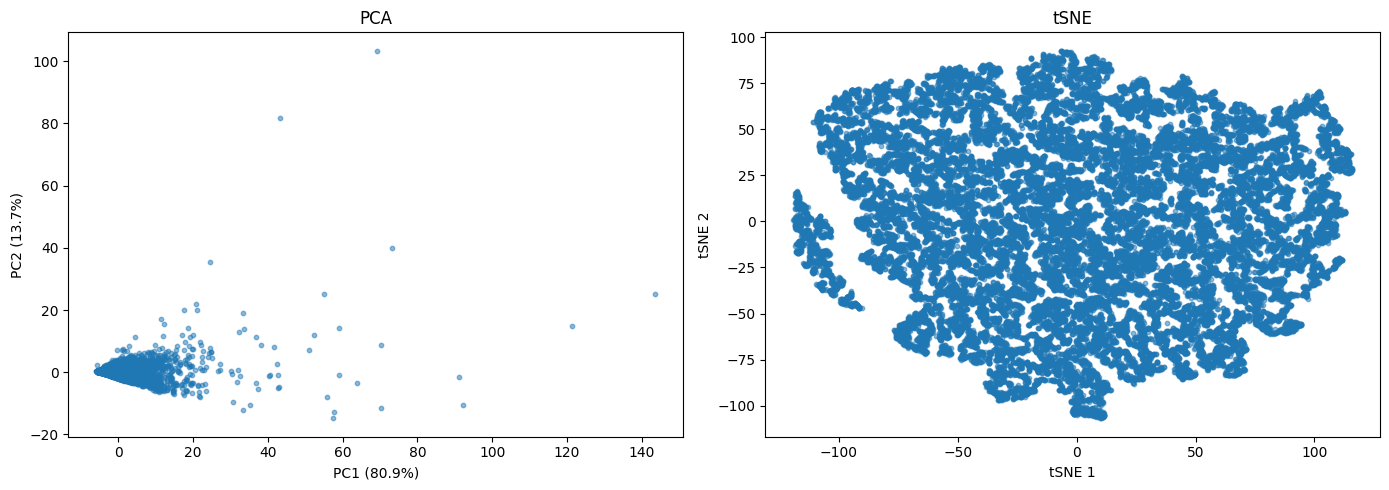

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# Normalize the red channel columns (exclude 'image' column)
scaler = StandardScaler()
red_cols_normalized = scaler.fit_transform(red_channel_df.iloc[:, 1:])

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(red_cols_normalized)

# Apply tSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(red_cols_normalized)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA plot
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA')

# tSNE plot
axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, s=10)
axes[1].set_xlabel('tSNE 1')
axes[1].set_ylabel('tSNE 2')
axes[1].set_title('tSNE')

plt.tight_layout()
plt.show()

In [8]:
tsne

,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the random number generator. Pass an int for reproducibleresults across multiple function calls. Note that differentinitializations might result in different local minima of the costfunction. See :term:`Glossary <random_state>`.",42
,"n_components n_components: int, default=2Dimension of the embedded space.",2
,"perplexity perplexity: float, default=30.0The perplexity is related to the number of nearest neighbors thatis used in other manifold learning algorithms. Larger datasetsusually require a larger perplexity. Consider selecting a valuebetween 5 and 50. Different values can result in significantlydifferent results. The perplexity must be less than the numberof samples.",30
,"early_exaggeration early_exaggeration: float, default=12.0Controls how tight natural clusters in the original space are inthe embedded space and how much space will be between them. Forlarger values, the space between natural clusters will be largerin the embedded space. Again, the choice of this parameter is notvery critical. If the cost function increases during initialoptimization, the early exaggeration factor or the learning ratemight be too high.",12.0
,"learning_rate learning_rate: float or ""auto"", default=""auto""The learning rate for t-SNE is usually in the range [10.0, 1000.0]. Ifthe learning rate is too high, the data may look like a 'ball' with anypoint approximately equidistant from its nearest neighbours. If thelearning rate is too low, most points may look compressed in a densecloud with few outliers. If the cost function gets stuck in a bad localminimum increasing the learning rate may help.Note that many other t-SNE implementations (bhtsne, FIt-SNE, openTSNE,etc.) use a definition of learning_rate that is 4 times smaller thanours. So our learning_rate=200 corresponds to learning_rate=800 inthose other implementations. The 'auto' option sets the learning_rateto `max(N / early_exaggeration / 4, 50)` where N is the sample size,following [4] and [5]... versionchanged:: 1.2 The default value changed to `""auto""`.",'auto'
,"max_iter max_iter: int, default=1000Maximum number of iterations for the optimization. Should be atleast 250... versionchanged:: 1.5 Parameter name changed from `n_iter` to `max_iter`.",1000
,"n_iter_without_progress n_iter_without_progress: int, default=300Maximum number of iterations without progress before we abort theoptimization, used after 250 initial iterations with earlyexaggeration. Note that progress is only checked every 50 iterations sothis value is rounded to the next multiple of 50... versionadded:: 0.17 parameter *n_iter_without_progress* to control stopping criteria.",300
,"min_grad_norm min_grad_norm: float, default=1e-7If the gradient norm is below this threshold, the optimization willbe stopped.",1e-07
,"metric metric: str or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string, it must be one of the optionsallowed by scipy.spatial.distance.pdist for its metric parameter, ora metric listed in pairwise.PAIRWISE_DISTANCE_FUNCTIONS.If metric is ""precomputed"", X is assumed to be a distance matrix.Alternatively, if metric is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays from X as input and return a value indicatingthe distance between them. The default is ""euclidean"" which isinterpreted as squared euclidean distance.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 1.1",None
,"init init: {""random"", ""pca""} or ndarray of shape (n_samples, n_components), default=""pca""Initialization of embedding.PCA initialization cannot be used with precomputed distances and isusually more globally stable than random initialization... versionchanged:: 1.2 The default value changed t

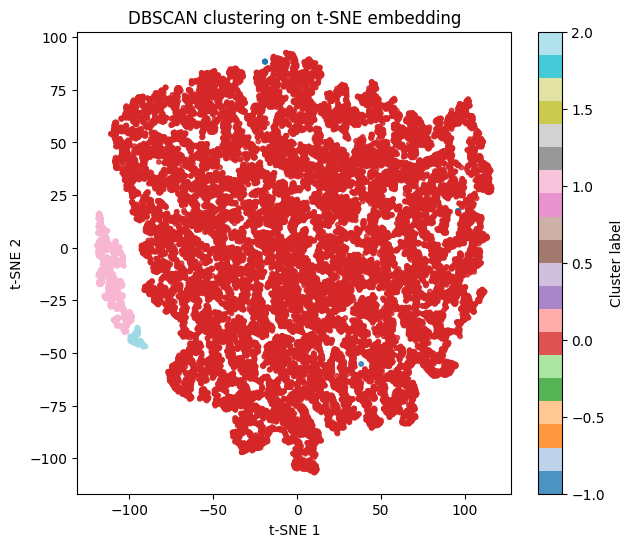

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# tsne should be an array of shape (n_points, 2)
# e.g. tsne = TSNE(...).fit_transform(X)

clustering = DBSCAN(
    eps=3.0,          # adjust this
    min_samples=10    # adjust this
).fit(tsne_result)

labels = clustering.labels_

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=labels,
    cmap="tab20",
    s=10,
    alpha=0.8
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("DBSCAN clustering on t-SNE embedding")
plt.colorbar(scatter, label="Cluster label")
plt.show()

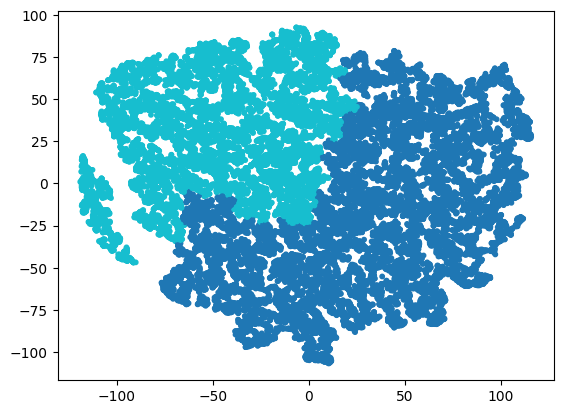

In [10]:
from sklearn.cluster import AgglomerativeClustering

clusterer = AgglomerativeClustering(n_clusters=2)
labels = clusterer.fit_predict(tsne_result)

plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap="tab10", s=10)
plt.show()

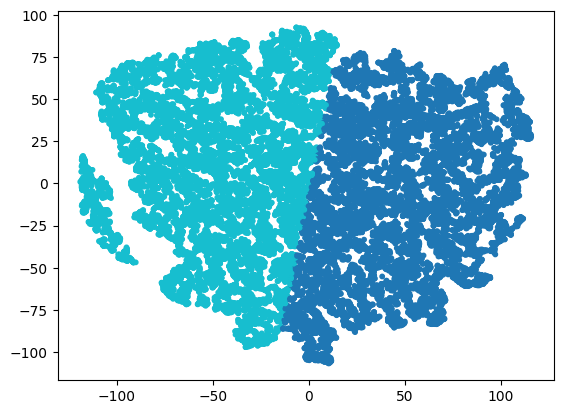

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(tsne_result)

plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap="tab10", s=10)
plt.show()

In [13]:
red_cols_normalized

array([[-0.76555561, -0.25566686, -1.2387481 , ..., -0.44124466,
        -0.50812836, -0.59496181],
       [-0.68652878, -0.34711884, -1.15345223, ..., -0.55116703,
        -0.56689799, -0.58232486],
       [-0.18774986, -0.10790672, -0.42843733, ..., -0.05040959,
        -0.07715106, -0.2048593 ],
       ...,
       [-1.45082982, -0.8492282 , -1.2387481 , ..., -1.2961964 ,
        -1.2329538 , -1.10043964],
       [-1.52795832, -0.86388003, -1.3666919 , ..., -1.34505078,
        -1.28192849, -1.132032  ],
       [-1.62822426, -0.90409429, -1.45198777, ..., -1.43054595,
        -1.35049306, -1.18257978]])

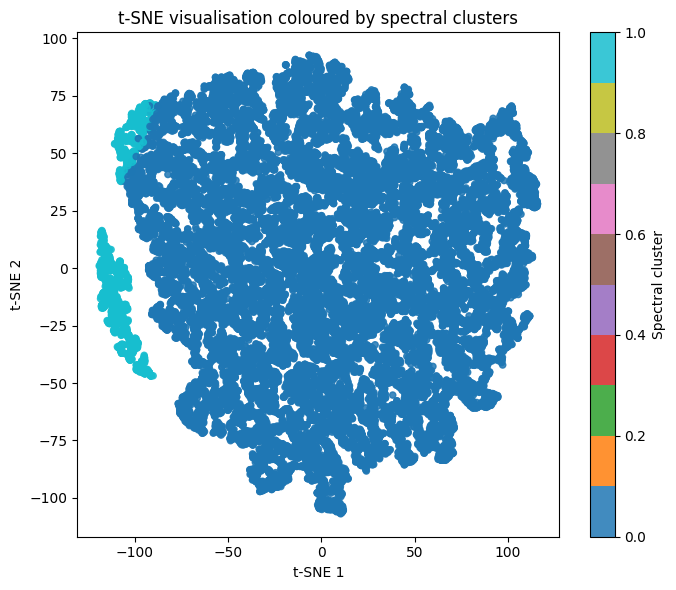

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.manifold import TSNE

# X = your raw data table
# shape: n_samples x n_features
# For example:
# X = df.values

# 1. Scale raw features
X_scaled = StandardScaler().fit_transform(red_cols_normalized)

# 2. Spectral clustering on the raw/scaled table
clusterer = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=42
)

labels = clusterer.fit_predict(X_scaled)

# 3. t-SNE only for visualisation
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# 4. Plot t-SNE coloured by spectral clusters
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    cmap="tab10",
    s=20,
    alpha=0.85
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualisation coloured by spectral clusters")
plt.colorbar(scatter, label="Spectral cluster")
plt.tight_layout()
plt.show()

In [15]:
np.unique(labels, return_counts=True)

(array([0, 1], dtype=int32), array([31897,  1505]))

In [17]:
cluster2_indices = np.where(labels == 1)[0]
print(cluster2_indices)

[   13    14    15 ... 33399 33400 33401]


In [24]:
df_cluster2 = combined_df[labels == 1]
df_subset_cluster2 = df[["label", "image"]]
df_subset_cluster2.head()

,label,image
0,1,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
1,2,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
2,3,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
3,4,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...
4,5,F2445_CHST11KO+P301S_MC_AT8_epsilon1_fourth_20...


In [36]:
from pathlib import Path
import re
import math

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

# Folder containing subfolders with ROI images
qc_folder = Path(INPUT_ROOT / "qc_crops")
print(f"QC folder: {qc_folder}")

# Example: cluster 2 IDs extracted from your dataframe
# This should contain labels such as 126, 54, 8, ...
cluster2_labels = df_cluster2["label"].astype(int).tolist()
print(f"Cluster 2 labels: {cluster2_labels}")

label_pattern = re.compile(r"label(\d+)", re.IGNORECASE)

matched_files = []

for file in qc_folder.rglob("*.tif"):
    match = label_pattern.search(file.name)
    if match is None:
        continue

    label_id = int(match.group(1))

    if label_id in cluster2_labels:
        matched_files.append(file)

print(f"Found {len(matched_files)} matching TIFF files")

QC folder: N:\01_scientific_data\Sarah_Kralova_brain_slice_data\cellpose + far-red channel\qc_crops
Cluster 2 labels: [14, 15, 16, 17, 18, 22, 39, 41, 56, 59, 62, 63, 84, 85, 87, 95, 97, 98, 105, 106, 107, 115, 124, 135, 138, 151, 157, 171, 176, 203, 224, 231, 310, 316, 398, 412, 418, 428, 433, 445, 452, 455, 461, 471, 475, 486, 488, 495, 497, 498, 499, 500, 503, 504, 506, 508, 509, 510, 514, 515, 519, 520, 523, 524, 525, 526, 527, 528, 529, 572, 644, 662, 712, 713, 714, 748, 749, 752, 757, 767, 774, 784, 845, 880, 925, 932, 934, 963, 985, 986, 989, 992, 993, 997, 1000, 1006, 1012, 1017, 1023, 1036, 1039, 1049, 1054, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1066, 1067, 1068, 1075, 1299, 1346, 1374, 1575, 1582, 1586, 1595, 1606, 1608, 1616, 1632, 1716, 1737, 1750, 1770, 1781, 1782, 1783, 1787, 1800, 1808, 1818, 1820, 1825, 1826, 1829, 1849, 1858, 1860, 1874, 1893, 1898, 1909, 1912, 1914, 1917, 1919, 1921, 1925, 2327, 2560, 2615, 2623, 2628, 2629, 2631, 2632, 2633, 3150, 4353, 482

KeyboardInterrupt: 

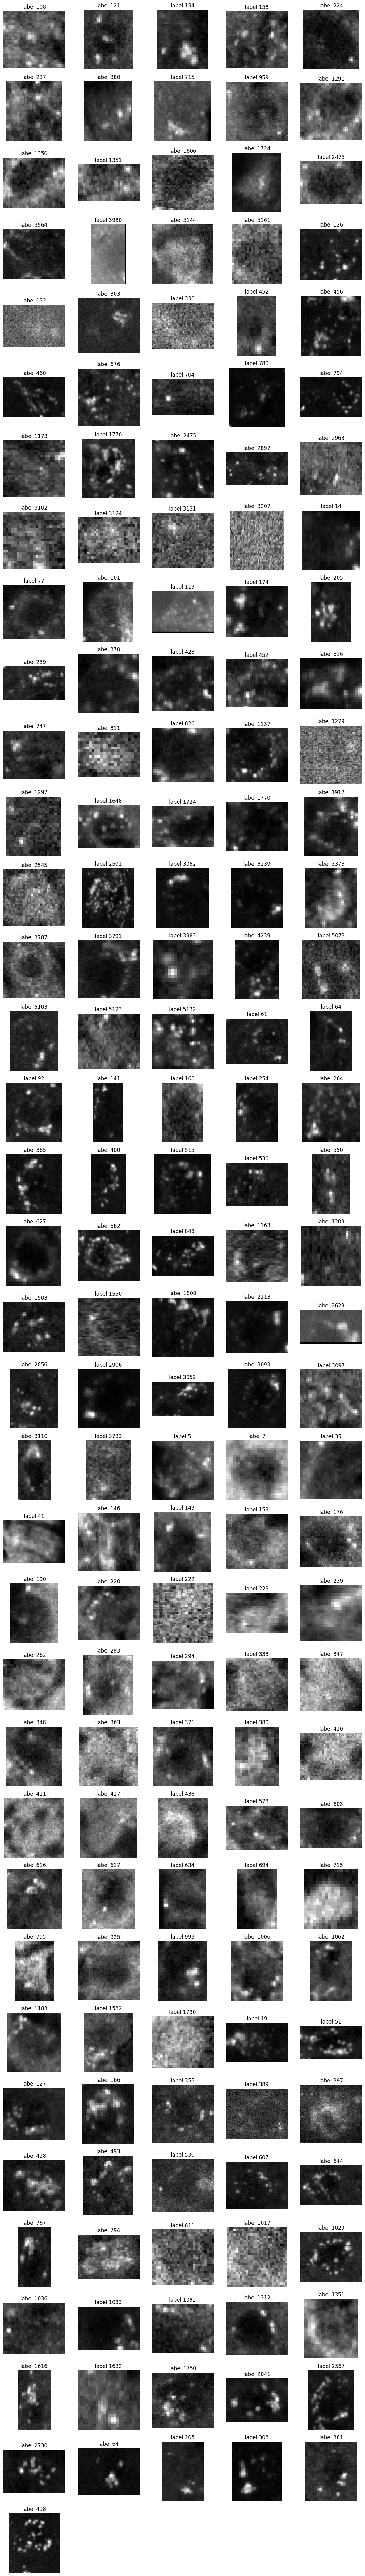

In [38]:
def make_mip(path):
    img = tiff.imread(path)
    img = img[1, :, :, :]

    # If image is ZYX: max over Z
    if img.ndim == 3:
        mip = img.max(axis=0)

    # If image is already 2D
    elif img.ndim == 2:
        mip = img

    # If image is multi-channel, adjust depending on your data
    # Example assumes CZYX or ZCYX may need manual checking
    else:
        raise ValueError(f"Unexpected image shape {img.shape} for {path}")

    return mip


n = len(matched_files)
cols = 5
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 3, rows * 3))

for i, file in enumerate(matched_files):
    mip = make_mip(file)

    match = label_pattern.search(file.name)
    label_id = int(match.group(1))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(mip, cmap="gray")
    plt.title(f"label {label_id}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
def make_mip(path):
    img = tiff.imread(path)
    img = img[1, :, :, :]

    # If image is ZYX: max over Z
    if img.ndim == 3:
        mip = img.max(axis=0)

    # If image is already 2D
    elif img.ndim == 2:
        mip = img

    # If image is multi-channel, adjust depending on your data
    # Example assumes CZYX or ZCYX may need manual checking
    else:
        raise ValueError(f"Unexpected image shape {img.shape} for {path}")

    return mip

In [41]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# matched_files = list of TIFF paths
# make_mip = your function returning RGB overlay MIP

current_index = 0
out = widgets.Output()

button_prev = widgets.Button(description="← Previous")
button_next = widgets.Button(description="Next →")
label = widgets.Label()


def show_image(index):
    with out:
        clear_output(wait=True)

        file = matched_files[index]
        mip = make_mip(file)

        label.value = f"{index + 1} / {len(matched_files)}   {file.name}"

        plt.figure(figsize=(6, 6))
        plt.imshow(mip)
        plt.axis("off")
        plt.title(file.name)
        plt.show()


def on_prev_clicked(b):
    global current_index
    current_index = (current_index - 1) % len(matched_files)
    show_image(current_index)


def on_next_clicked(b):
    global current_index
    current_index = (current_index + 1) % len(matched_files)
    show_image(current_index)


button_prev.on_click(on_prev_clicked)
button_next.on_click(on_next_clicked)

controls = widgets.HBox([button_prev, button_next, label])
display(controls, out)

show_image(current_index)

Output()

In [ ]:
cluster1_indices = np.where(labels == 0)[0]
print(cluster1_indices)

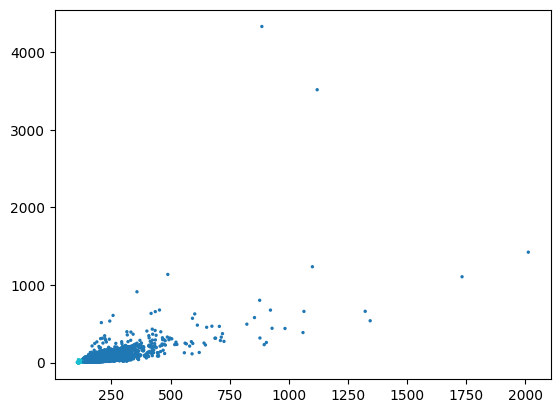

In [42]:
plt.scatter(combined_df["intensity_mean_red"], combined_df["intensity_std_red"], c=labels, cmap="tab10", s=2)

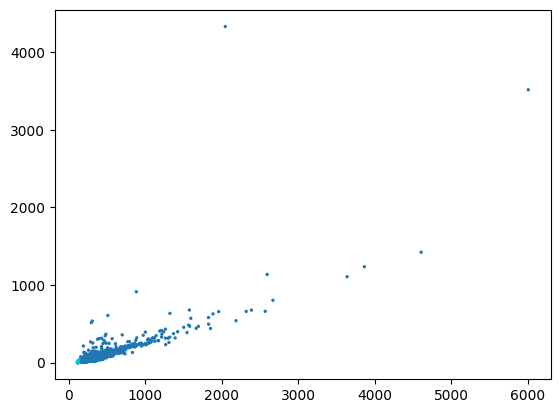

In [43]:
plt.scatter(combined_df["intensity_p95_red"], combined_df["intensity_std_red"], c=labels, cmap="tab10", s=2)

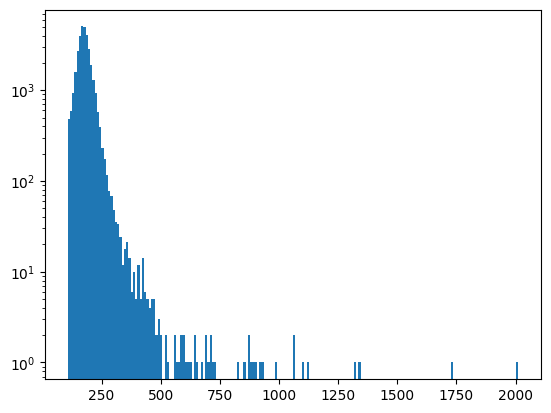

In [49]:
plt.hist(combined_df["intensity_mean_red"], bins=200)
plt.yscale("log")

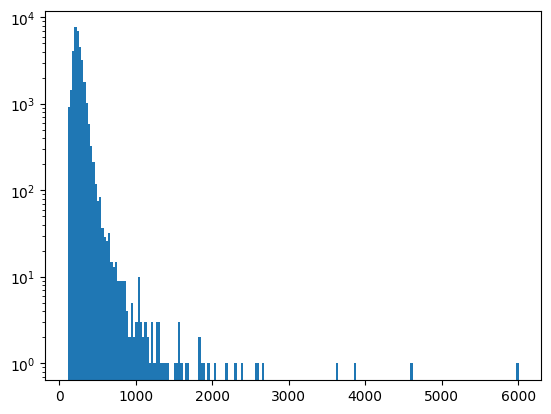

In [50]:
plt.hist(combined_df["intensity_p95_red"], bins=200)
plt.yscale("log")

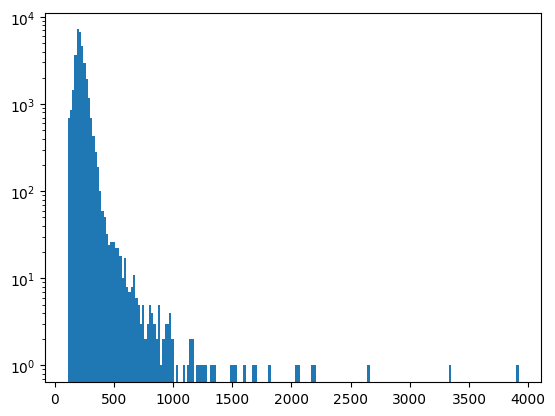

In [51]:
plt.hist(combined_df["intensity_p90_red"], bins=200)
plt.yscale("log")

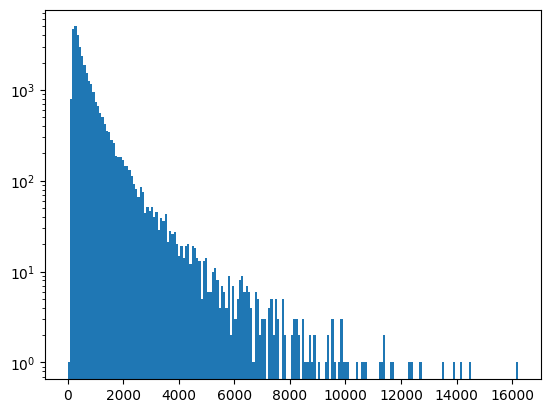

In [57]:
plt.hist(combined_df["intensity_p10_farred"], bins=200)
plt.yscale("log")